# Classification - Are Climates Becoming More Similar To Each Other?

In [404]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


In [412]:
train_df = pd.read_csv('weather_train.csv')
test_df = pd.read_csv('weather_test.csv')

train_df = train_df[train_df['CITY'] != 'CHICAGO']
test_df = test_df[test_df['CITY'] != 'CHICAGO']

train_df['DATE'] = pd.to_datetime(train_df['DATE'])
train_df['Year'] = train_df['DATE'].dt.year
train_df['Month'] = train_df['DATE'].dt.month

test_df['DATE'] = pd.to_datetime(test_df['DATE'])
test_df['Year'] = test_df['DATE'].dt.year
test_df['Month'] = test_df['DATE'].dt.month

In [416]:
# Get rid of extra test columns 
test_columns = test_df.columns.tolist() 
train_columns = train_df.columns.tolist() 

for column_name in test_columns: 
    if column_name not in train_columns: 
        test_df = test_df.drop([column_name], axis=1)

In [418]:
# Make sure the columns are in the same order 
test_df = test_df[train_df.columns]

In [420]:
train_df = train_df.drop(['DATE'], axis=1)
test_df = test_df.drop(['DATE'], axis=1)

In [422]:
train_df.columns.tolist()

['Unnamed: 0',
 'DailyAverageDryBulbTemperature',
 'DailyCoolingDegreeDays',
 'DailyDepartureFromNormalAverageTemperature',
 'DailyHeatingDegreeDays',
 'DailyMaximumDryBulbTemperature',
 'DailyMinimumDryBulbTemperature',
 'DailyPeakWindDirection',
 'DailyPeakWindSpeed',
 'DailyPrecipitation',
 'DailySnowDepth',
 'DailySnowfall',
 'CITY',
 'Year',
 'Month']

In [424]:
train_df = train_df.groupby(['Year', 'Month', 'CITY'])[['DailyAverageDryBulbTemperature',
       'DailyCoolingDegreeDays', 'DailyDepartureFromNormalAverageTemperature',
       'DailyHeatingDegreeDays', 'DailyMaximumDryBulbTemperature',
       'DailyMinimumDryBulbTemperature', 'DailyPeakWindDirection',
       'DailyPeakWindSpeed', 'DailyPrecipitation', 'DailySnowDepth',
       'DailySnowfall']].mean().reset_index()
test_df = test_df.groupby(['Year', 'Month', 'CITY'])[['DailyAverageDryBulbTemperature',
       'DailyCoolingDegreeDays', 'DailyDepartureFromNormalAverageTemperature',
       'DailyHeatingDegreeDays', 'DailyMaximumDryBulbTemperature',
       'DailyMinimumDryBulbTemperature', 'DailyPeakWindDirection',
       'DailyPeakWindSpeed', 'DailyPrecipitation', 'DailySnowDepth',
       'DailySnowfall']].mean().reset_index()

In [426]:
train_df.head(5)

,Year,Month,CITY,DailyAverageDryBulbTemperature,DailyCoolingDegreeDays,DailyDepartureFromNormalAverageTemperature,DailyHeatingDegreeDays,DailyMaximumDryBulbTemperature,DailyMinimumDryBulbTemperature,DailyPeakWindDirection,DailyPeakWindSpeed,DailyPrecipitation,DailySnowDepth,DailySnowfall
0,1950,1,BOSTON,34.269231,0.0,4.469231,30.615385,43.153846,25.153846,250.230769,31.884615,0.145192,0.231346,0.305000
1,1950,1,MIAMI,73.100000,8.1,4.520000,0.000000,78.933333,67.300000,100.066667,23.166667,0.018667,0.000000,0.000000
2,1950,1,SAN FRANCISCO,46.016667,0.0,-5.840000,18.800000,51.866667,39.983333,0.000000,0.000000,0.228833,0.000000,0.000333
3,1950,1,WINSLOW,0.000000,0.0,-1.106667,29.900000,50.366667,19.366667,0.000000,0.000000,0.001000,0.000000,0.007333
4,1950,2,BOSTON,28.000000,0.0,-3.860714,36.750000,35.428571,20.500000,226.785714,32.107143,0.138036,1.750536,0.544821


In [428]:
# Get features and labels
X_train = train_df.drop(['CITY', 'Year'], axis=1)
y_train = train_df['CITY']

X_test = test_df.drop(['CITY', 'Year'], axis=1)
y_test = test_df['CITY']

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [430]:
# Train classifier on present day data
test_clf = RandomForestClassifier(random_state=42)
test_clf.fit(X_test_scaled, y_test)

RandomForestClassifier(random_state=42)

In [432]:
y_pred_past_train = clf.predict(X_train_scaled)
y_pred_past_test = clf.predict(X_test_scaled)
y_pred_present_train = test_clf.predict(X_test_scaled)
y_pred_present_test = test_clf.predict(X_train_scaled)

Classification Report: Past Model Training Performance
               precision    recall  f1-score   support

       BOSTON       1.00      1.00      1.00       121
        MIAMI       1.00      1.00      1.00       121
SAN FRANCISCO       1.00      1.00      1.00       121
      WINSLOW       1.00      1.00      1.00       121

     accuracy                           1.00       484
    macro avg       1.00      1.00      1.00       484
 weighted avg       1.00      1.00      1.00       484



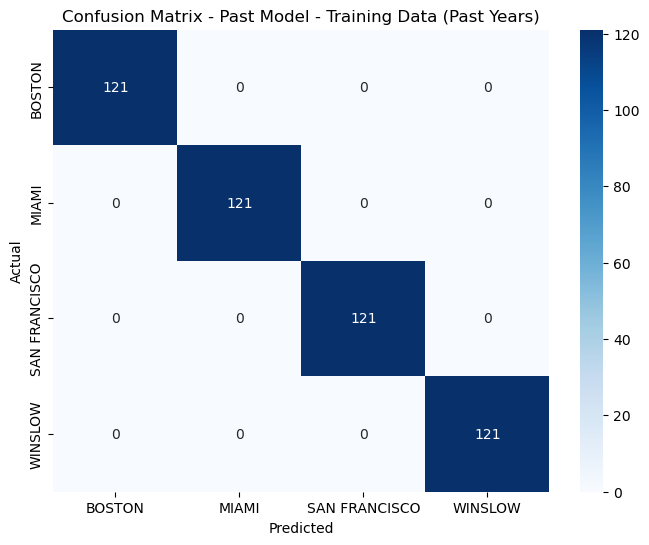

In [450]:
# Model trained on Past Data 
print("Classification Report: Past Model Training Performance")
print(classification_report(y_train, y_pred_past_train))

# Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_train, y_pred_past_train), annot=True, fmt='d', 
            xticklabels=clf.classes_, yticklabels=clf.classes_, cmap='Blues')
plt.title("Confusion Matrix - Past Model - Training Data (Past Years)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Classification Report: Past Model Testing Performance
               precision    recall  f1-score   support

       BOSTON       0.35      1.00      0.51        37
        MIAMI       0.97      0.97      0.97        33
SAN FRANCISCO       0.00      0.00      0.00        33
      WINSLOW       0.00      0.00      0.00        37

     accuracy                           0.49       140
    macro avg       0.33      0.49      0.37       140
 weighted avg       0.32      0.49      0.36       140



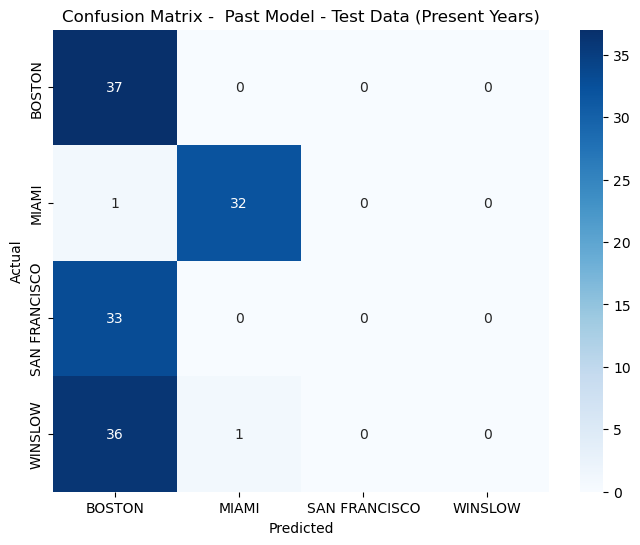

In [448]:
print("Classification Report: Past Model Testing Performance")
print(classification_report(y_test, y_pred_past_test))

# Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_past_test), annot=True, fmt='d', 
            xticklabels=clf.classes_, yticklabels=clf.classes_, cmap='Blues')
plt.title("Confusion Matrix -  Past Model - Test Data (Present Years)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Classification Report: Present Model Training Performance
               precision    recall  f1-score   support

       BOSTON       1.00      1.00      1.00        37
        MIAMI       1.00      1.00      1.00        33
SAN FRANCISCO       1.00      1.00      1.00        33
      WINSLOW       1.00      1.00      1.00        37

     accuracy                           1.00       140
    macro avg       1.00      1.00      1.00       140
 weighted avg       1.00      1.00      1.00       140



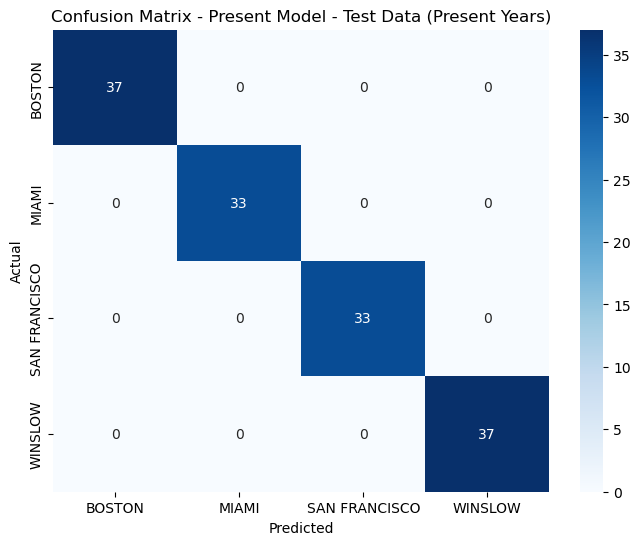

In [442]:
print("Classification Report: Present Model Training Performance")
print(classification_report(y_test, y_pred_present_train))

# Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_present_train), annot=True, fmt='d', 
            xticklabels=clf.classes_, yticklabels=clf.classes_, cmap='Blues')
plt.title("Confusion Matrix - Present Model - Test Data (Present Years)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Classification Report: Present Model Testing Performance
               precision    recall  f1-score   support

       BOSTON       0.75      0.91      0.82       121
        MIAMI       0.88      0.87      0.88       121
SAN FRANCISCO       0.91      0.87      0.89       121
      WINSLOW       0.94      0.79      0.86       121

     accuracy                           0.86       484
    macro avg       0.87      0.86      0.86       484
 weighted avg       0.87      0.86      0.86       484



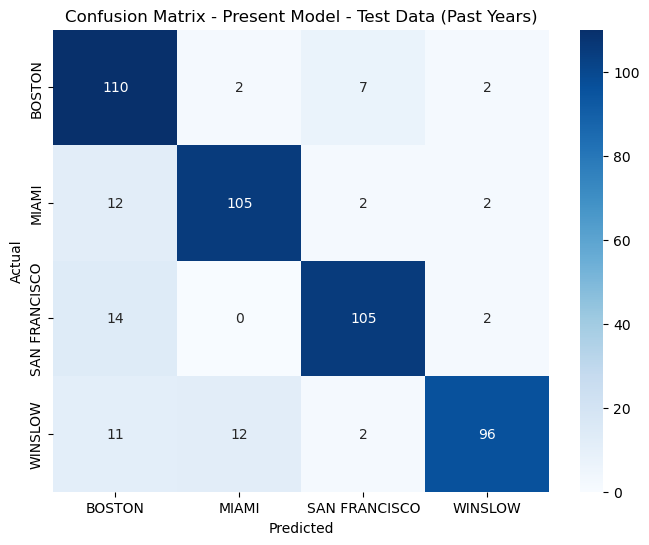

In [444]:
print("Classification Report: Present Model Testing Performance")
print(classification_report(y_train, y_pred_present_test))

# Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_train, y_pred_present_test), annot=True, fmt='d', 
            xticklabels=clf.classes_, yticklabels=clf.classes_, cmap='Blues')
plt.title("Confusion Matrix - Present Model - Test Data (Past Years)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [184]:
# Combine train and test for full timeline analysis
full_processed = pd.concat([train_df, test_df])

# Group by city and year
city_year_climate = full_processed.groupby(['CITY', 'Year']).mean().reset_index()


In [186]:
# Drop Chicago
full_processed_filtered = full_processed[full_processed['CITY'] != 'CHICAGO']


In [188]:
from scipy.spatial.distance import pdist

distance_results = []

years = full_processed_filtered['Year'].unique()

for year in sorted(years):
    year_df = full_processed_filtered[full_processed_filtered['Year'] == year]
    
    if year_df['CITY'].nunique() < 4:
        continue  # Skip years with fewer than 4 cities
    
    features = year_df.drop(columns=['CITY', 'Year']).values
    distances = pdist(features, metric='euclidean')
    avg_distance = distances.mean()
    
    distance_results.append({
        'Year': year,
        'Average_Pairwise_Distance': avg_distance
    })

distance_df = pd.DataFrame(distance_results)


In [484]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist

distance_results = []

years = full_processed_filtered['Year'].unique()

for year in sorted(years):
    year_df = full_processed_filtered[full_processed_filtered['Year'] == year]
    
    if year_df['CITY'].nunique() < 4:
        continue  # Skip years with fewer than 4 cities

    features = year_df.drop(columns=['CITY', 'Year']).values

    distances = pdist(features, metric='euclidean')
    avg_distance = distances.mean()
    
    distance_results.append({
        'Year': year,
        'Average_Pairwise_Distance': avg_distance
    })

distance_df = pd.DataFrame(distance_results)

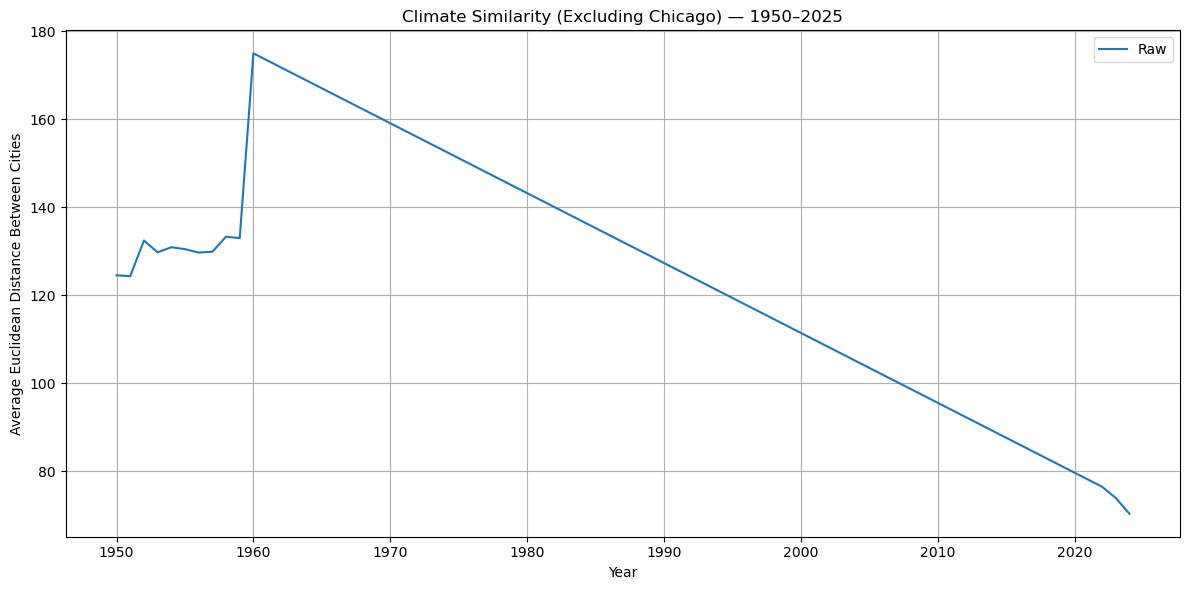

In [486]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=distance_df, x='Year', y='Average_Pairwise_Distance', label='Raw')


plt.title('Climate Similarity (Excluding Chicago) — 1950–2025')
plt.xlabel('Year')
plt.ylabel('Average Euclidean Distance Between Cities')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

